## Plotting the density profile of the halos using different mass assignment schemes

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import bigfile
import tarfile
import os
from IPython.display import clear_output
from scipy.optimize import curve_fit

In [46]:
# Plot styles

def style_axes():
    ax = plt.gca()
    ax.set_facecolor('black')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_color('white')
    plt.axis('equal')

def style_cbar(im, label=''):
    cbar = plt.colorbar(im, cax=plt.gca())  
    cbar.set_label(label, color='white')
    cbar.ax.tick_params(color='white')
    plt.setp(cbar.ax.get_yticklabels(), color='white')

In [47]:
# Load data

# SIM_PATH = "/storage/nkhandai/simulation_data/MP-Gadget/hydro_stellar-bhkinetic-bhthermal/MP-Gadget_version_20230411/default_cosmology/50Mpc_640cube/output"

# Load halo data
# with tarfile.open(os.path.join(SIM_PATH, "PIG_171/FOFGroups.tgz"), 'r:gz') as tar:
#     tar.extractall(path='/data/gayatri/PIG_171')

# Load gas data
# with tarfile.open(os.path.join(SIM_PATH, "PIG_171/0.tgz"), 'r:gz') as tar:
#     tar.extractall(path='/data/gayatri/PIG_171')

In [48]:
SIM_PATH = '../simulations/L100N64_Hydro/SNAPS/PIG_031/'

In [49]:
halo =  bigfile.File(SIM_PATH+'FOFGroups')
print(os.listdir(SIM_PATH+'FOFGroups'))

['GasMetalElemMass', 'GroupID', 'MassCenterPosition', 'Jmom', 'BlackholeMass', 'MinID', 'StellarMetalMass', 'StellarMetalElemMass', 'GasMetalMass', 'Imom', 'MassCenterVelocity', 'Mass', 'FirstPos', 'BlackholeAccretionRate', 'MassHeIonized', 'LengthByType', 'MassByType', 'StarFormationRate']


In [50]:
gas = bigfile.File(SIM_PATH+'0')
print(os.listdir(SIM_PATH+'0'))

['Metals', 'Metallicity', 'InternalEnergy', 'ElectronAbundance', 'GroupID', 'ID', 'HeIIIIonized', 'SmoothingLength', 'Density', 'Generation', 'Mass', 'EgyWtDensity', 'Potential', 'NeutralHydrogenFraction', 'Position', 'DelayTime', 'Velocity', 'StarFormationRate']


In [51]:
halo_data = bigfile.Dataset(halo, ["GroupID", "MassCenterPosition"])
gas_data = bigfile.Dataset(gas, ["GroupID", "Position", "Mass"])

/home/gayatri/Desktop/codes/.cosmo/lib/python3.12/site-packages/bigfile/__init__.py:358: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  return pyxbigfile.Dataset.__init__(self, file, dtype=dtype, size=size)


In [52]:
# Take the most massive halos to work with

halo_mass = np.array([i for i in halo_data["Mass"][:]])
halo_id = np.array([i for i in halo_data["GroupID"][:]])

top_indices = np.argsort(halo_mass)[-2:]        # top 3 massive halos

top_halo_id = np.array([halo_id[i] for i in top_indices])

In [53]:
# Get the position of the centre of mass of the top halos

halo_center_pos = np.array([halo_data["MassCenterPosition"][:][i] for i in top_indices])

In [54]:
halo_center_pos

array([[ 9352.3988492 , 16356.84992953, 35047.64294871],
       [98951.57600688, 92456.09726418, 60296.89138906]])

In [55]:
x = halo_data["MassCenterPosition"][:][:,0]
y = halo_data["MassCenterPosition"][:][:,1]
z = halo_data["MassCenterPosition"][:][:,2]

In [56]:
# Get the position and mass of each of the gas particles lying in a particular halo
# Make use of dictionaries

gas_pos = {}
gas_mass = {}

In [57]:
gas_data['Position']

<CBigBlock: b'../simulations/L100N64_Hydro/SNAPS/PIG_031/0/Position' dtype=('<f8', (3,)), size=58661>

In [37]:
for i in range(len(top_halo_id)):
    id = top_halo_id[i]
    part_indices = np.where(halo_data["GroupID"][:]==id)
    print('Step 1 done')
    gas_pos[id] = [gas_data["Position"][i] for i in part_indices[0]]
    print('Step 2 done')
    gas_mass[id] = [gas_data["Mass"][i]*1e10 for i in part_indices[0]]
    print('Step 3 done')

Step 1 done
Step 2 done
Step 3 done
Step 1 done
Step 2 done
Step 3 done


In [58]:
# define the periodic boundary condition

def pbc(pos, cen_pos, L_box=100):
    # all positions are in the units of Mpc
    x = np.array([i[0]/1000 for i in pos])
    y = np.array([i[1]/1000 for i in pos])

    cx = cen_pos[0]/1000
    cy = cen_pos[1]/1000

    for i in range(len(x)):
        dx = x[i]-cx
        x[i] = dx + int(2*abs(dx)/L_box)*L_box
        dy = y[i]-cy
        y[i] = dy + int(2*abs(dy)/L_box)*L_box
    
    return x,y

# the centre is now shifted to the position of the centre of mass

In [65]:
for i in range(len(top_halo_id)):
    id = top_halo_id[i]
    x, y = pbc(gas_pos[id], halo_center_pos[i])
    plt.figure(figsize=(5,5), facecolor='k')
    style_axes()
    plt.scatter(x,y)#, c=f'C{i}', marker='.', s=0.1, alpha=1)
    plt.axis('equal')
    plt.title(f'Halo ID: {id}')
    plt.show()

KeyError: 2

### Nearest Grid Point (NGP)

In [43]:
# defining the mass the assignment

def floor(n):
    if n==0:
        return 0
    elif int(n)==n:
        return n-1
    else:
        return np.floor(n)

def ceil(n):
    if n==0:
        return 1
    else:
        return np.ceil(n)

def ngp_grid_coord(pos_x, pos_y, mass, N_grid=1024, scale_unit = 'Mpc', scale_length=0.25, cmap='inferno'):            # This function plots log10(2+delta)

    x = np.copy(pos_x)
    y = np.copy(pos_y)
    
    #defining the grid points
    x_g = np.arange(0.5, N_grid, 1)
    y_g = np.arange(0.5, N_grid, 1)
    density = {}
    for i in x_g:
        for j in y_g:
            density[(i,j)] = 0

    # converting the positions to the grid coordinates
    x_max, x_min = np.max(x), np.min(x)
    y_max, y_min = np.max(y), np.min(y)
    L_x = x_max-x_min
    L_y = y_max-y_min
    L = max(L_x, L_y)
    dx = abs(L-L_x)/2
    dy = abs(L-L_y)/2
    area = L_x*L_y/N_grid**2
    for i in range(len(x)):
        x[i] = (x[i]-x_min + dx)*N_grid/L
        y[i] = (y[i]-y_min + dy)*N_grid/L

        # compute the density
        density[((floor(x[i])+ceil(x[i]))/2, (floor(y[i])+ceil(y[i]))/2)] += mass[i]/area
    
    # make the density matrix
    density_mat = np.empty((N_grid, N_grid))
    mean_density = np.mean([density[key] for key in density.keys()])
    # delta_min = 1 - np.unique([density[key]/mean_density for key in density.keys()])[1]
    for key in density.keys():
        delta = density[key]/mean_density
        # if delta < 1:
        #     delta = 1
        density_mat[int(key[0]-0.5)][int(key[1]-0.5)] = np.log10(delta+1)
    
    plt.imshow(
        density_mat.T,              
        origin='lower',         
        # extent=[0, N_grid, 0, N_grid],
        extent=[0, L, 0, L],
        cmap=cmap,         
        interpolation='nearest' 
    )    
    scalebar = ScaleBar(1, scale_unit, dimension='astro-length', length_fraction=scale_length, location='lower right', box_alpha=0.1, color='white', animated=True, pad=0.5, width_fraction=0.003)
    plt.gca().add_artist(scalebar)
    plt.gca().set_xticks([])
    plt.gca().set_yticks([])

In [44]:
i = 0
id = top_halo_id[i]
x, y = pbc(gas_pos[id], halo_center_pos[i])
fig = plt.figure(figsize=(7,6), facecolor='k')
ngp_grid_coord(x, y, gas_mass[id], 1024, 'Mpc', 0.25)
style_axes()
# plt.colorbar().ax.tick_params(color='white')
plt.setp(plt.colorbar().ax.get_yticklabels(), color='white')
plt.show()

/tmp/ipykernel_27899/2631630267.py:40: RuntimeWarning: invalid value encountered in scalar divide
  x[i] = (x[i]-x_min + dx)*N_grid/L
/tmp/ipykernel_27899/2631630267.py:41: RuntimeWarning: invalid value encountered in scalar divide
  y[i] = (y[i]-y_min + dy)*N_grid/L


ValueError: cannot convert float NaN to integer

<Figure size 700x600 with 0 Axes>

### Cloud-in-Cloud (CIC)

In [ ]:
# defining the mass the assignment

def floor(n):
    if n==0:
        return 0
    elif int(n)==n:
        return n-1
    else:
        return np.floor(n)

def ceil(n):
    if n==0:
        return 1
    else:
        return np.ceil(n)

def cic_grid_coord(pos_x, pos_y, mass, N_grid=1024, scale_units='Mpc', scale_length=0.25):            # This function plots log10(1+delta + min(2-delta))

    x = np.copy(pos_x)
    y = np.copy(pos_y)
    
    #defining the grid points
    x_g = np.arange(0.5, N_grid, 1)
    y_g = np.arange(0.5, N_grid, 1)
    density = {}
    for i in x_g:
        for j in y_g:
            density[(i,j)] = 0

    # converting the positions to the grid coordinates
    x_max, x_min = np.max(x), np.min(x)
    y_max, y_min = np.max(y), np.min(y)
    L_x = x_max-x_min
    L_y = y_max-y_min
    L = max(L_x, L_y)
    dx = abs(L-L_x)/2
    dy = abs(L-L_y)/2
    area = L_x*L_y/N_grid**2
    for i in range(len(x)):
        x[i] = (x[i]-x_min + dx)*N_grid/L
        y[i] = (y[i]-y_min + dy)*N_grid/L

        # compute the density
        x1 = (floor(x[i])+ceil(x[i]))/2
        y1 = (floor(y[i])+ceil(y[i]))/2
        density[(x1, y1)] += mass[i]*(1-abs(x[i]-x1))*(1-abs(y[i]-y1))/area
        if x[i] <= x1:
            if y[i] <= y1:
                if y1 >= 1:
                    density[(x1, y1-1)] += mass[i]*(1-abs(x[i]-x1))*(y1-y[i])/area
                if x1 >= 1:
                    density[(x1-1, y1)] += mass[i]*(x1-x[i])*(1-abs(y[i]-y1))/area
                    if y1 >= 1:
                        density[(x1-1, y1-1)] += mass[i]*(x1-x[i])*(y1-y[i])/area
            else:
                if y1 <= N_grid-1:
                    density[(x1, y1+1)] += mass[i]*(1-abs(x[i]-x1))*(y[i]-y1)/area
                if x1 >= 1:
                    density[(x1-1, y1)] += mass[i]*(x1-x[i])*(1-abs(y[i]-y1))/area
                    if y1 <= N_grid-1:
                        density[(x1-1, y1+1)] += mass[i]*(x1-x[i])*(y[i]-y1)/area
        else:
            if y[i] <= y1:
                if y1 >= 1:
                    density[(x1, y1-1)] += mass[i]*(1-abs(x[i]-x1))*(y1-y[i])/area
                if x1 <= N_grid-1:
                    density[(x1+1, y1)] += mass[i]*(x[i]-x1)*(1-abs(y[i]-y1))/area
                    if y1 >= 1:
                        density[(x1+1, y1-1)] += mass[i]*(x[i]-x1)*(y1-y[i])/area
            else:
                if y1 <= N_grid-1:
                    density[(x1, y1+1)] += mass[i]*(1-abs(x[i]-x1))*(y[i]-y1)/area
                if x1 <= N_grid-1:
                    density[(x1+1, y1)] += mass[i]*(x[i]-x1)*(1-abs(y[i]-y1))/area
                    if y1 <= N_grid-1:
                        density[(x1+1, y1+1)] += mass[i]*(x[i]-x1)*(y[i]-y1)/area
        
    # make the density matrix
    density_mat = np.empty((N_grid, N_grid))
    mean_density = np.mean([density[key] for key in density.keys()])
    delta_min = 1 - np.unique([density[key]/mean_density for key in density.keys()])[1]
    # print(delta_min)
    for key in density.keys():
        delta = density[key]/mean_density
        # if delta < 1:
        #     delta = 1
        density_mat[int(key[0]-0.5)][int(key[1]-0.5)] = np.log10(delta+1)
    
    plt.imshow(
        density_mat.T,              
        origin='lower',         
        # extent=[0, N_grid, 0, N_grid],
        extent=[0, L, 0, L],
        cmap='inferno',         
        interpolation='nearest' 
    )    
    scalebar = ScaleBar(1, scale_units, dimension='astro-length', length_fraction=scale_length, location='lower right', box_alpha=0.1, color='white', animated=True, pad=0.5, width_fraction=0.003)
    plt.gca().add_artist(scalebar)
    plt.gca().set_xticks([])
    plt.gca().set_yticks([])

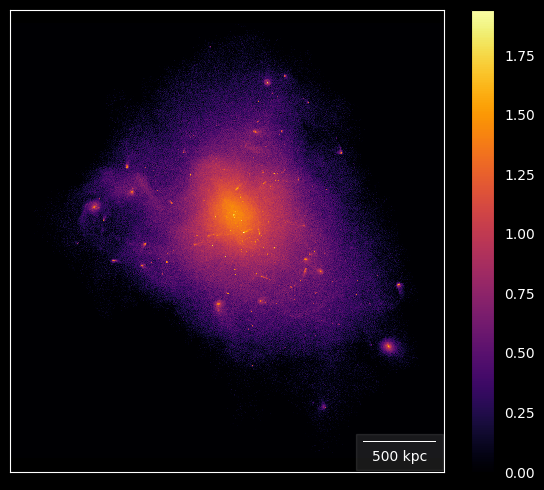

In [ ]:
i = 0
id = top_halo_id[i]
x, y = pbc(gas_pos[top_halo_id[i]], halo_center_pos[i])
plt.figure(figsize=(7,6), facecolor='k')
cic_grid_coord(x, y, gas_mass[top_halo_id[i]])
style_axes()
# plt.colorbar().ax.tick_params(color='white')
plt.setp(plt.colorbar().ax.get_yticklabels(), color='white')
plt.show()

#### Plotting box slices

In [ ]:
x_box = gas_data["Position"][:][:,0]/1000
y_box = gas_data["Position"][:][:,1]/1000
z_box = gas_data["Position"][:][:,2]/1000
box_gas_mass = gas_data["Mass"][:]*1e10

In [ ]:
z_mask = (z_box > 0) & (z_box < 5)
x_slice = x_box[z_mask]
y_slice = y_box[z_mask]

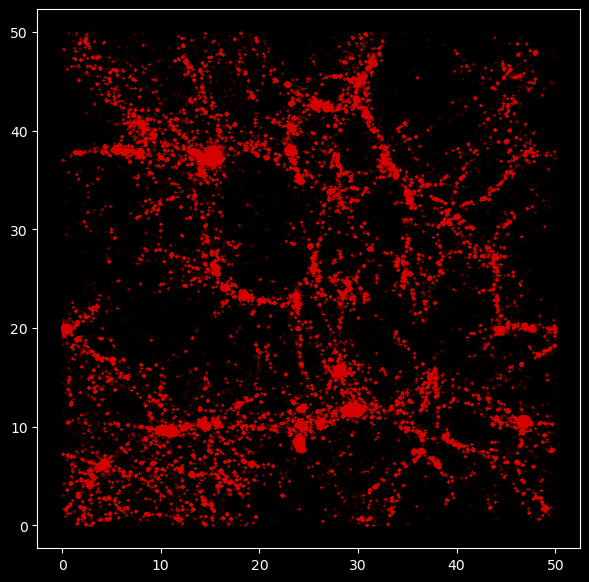

In [ ]:
plt.figure(figsize=(7,7), facecolor='k')
style_axes()
plt.scatter(x_slice, y_slice, c='r', marker='.', s=0.1, alpha=0.1)
plt.axis('equal')
plt.show()

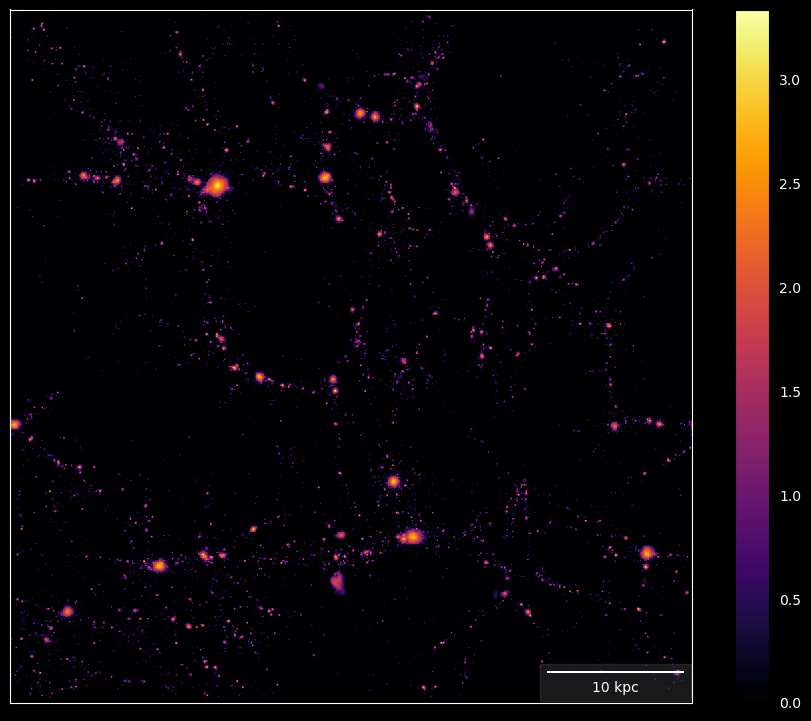

In [ ]:
plt.figure(figsize=(11,9), facecolor='k')
ngp_grid_coord(x_slice,y_slice, box_gas_mass[z_mask], 1024, 'kpc',0.25)
style_axes()
# plt.colorbar().ax.tick_params(color='white')
plt.setp(plt.colorbar().ax.get_yticklabels(), color='white')
# plt.savefig("/home/gayatri/halos_plots/PART_171_density_ngp.png")
plt.show()

In [ ]:
halo =  bigfile.File('/data/gayatri/PIG_171/FOFGroups')
print(os.listdir('/data/gayatri/PIG_171/FOFGroups'))